# Tile test: accuracy and classification time

Line plots for **concentric circles** and **plant tissue** CSVs (`circle_res.csv`, `plant_res.csv`).

Thanks CursorAI

In [7]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Load CSVs from repo root whether the kernel cwd is the project root or exploration_notebooks/


def _load_tile_test_csv(filename: str) -> pd.DataFrame:
    cwd = Path.cwd().resolve()
    for root in (cwd, cwd.parent):
        path = root / filename
        if path.is_file():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find {filename} under {cwd} or {cwd.parent}. "
        "Open the notebook from the repo or set the kernel cwd to exploration_notebooks/."
    )


circle_df = _load_tile_test_csv("circle_16x16_method_1_iso_0_torino_16x16_results.csv")
plant_df = _load_tile_test_csv("plant_2_16x16_method_1_iso-0.5_torino_results.csv")


def _tile_edge_and_sorted(df: pd.DataFrame, ycol: str) -> tuple[list[int], list[float]]:
    tmp = df.copy()
    tmp["_edge"] = tmp["tile_size"].astype(str).str.split("x").str[0].astype(int)
    tmp = tmp.sort_values("_edge")
    return tmp["_edge"].tolist(), tmp[ycol].astype(float).tolist()


def plot_mean_accuracy(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Mean accuracy vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of mean accuracy for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, "mean_accuracy")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Mean accuracy")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(set(_tile_edge_and_sorted(circle_df, "mean_accuracy")[0])))
    fig.tight_layout()
    return fig, ax


def plot_avg_classification_s(
    circle_df: pd.DataFrame,
    plant_df: pd.DataFrame,
    *,
    label_circle: str = "Synthetic dataset",
    label_plant: str = "Plant dataset",
    colors: tuple[str, str] = ("C0", "C1"),
    ax: plt.Axes | None = None,
    title: str | None = "Average Classification Time vs Tile Size",
) -> tuple[plt.Figure, plt.Axes]:
    """Line plot of avg_classification_s for both test images on one axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    for df, lab, color in zip((circle_df, plant_df), (label_circle, label_plant), colors):
        x, y = _tile_edge_and_sorted(df, "avg_classification_s")
        ax.plot(x, y, marker="o", linewidth=2, label=lab, color=color)

    ax.set_xlabel("Square tile size")
    ax.set_ylabel("Average classification time (s)")
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.set_xticks(sorted(set(_tile_edge_and_sorted(circle_df, "avg_classification_s")[0])))
    fig.tight_layout()
    return fig, ax

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\tile_test_mean_accuracy.png


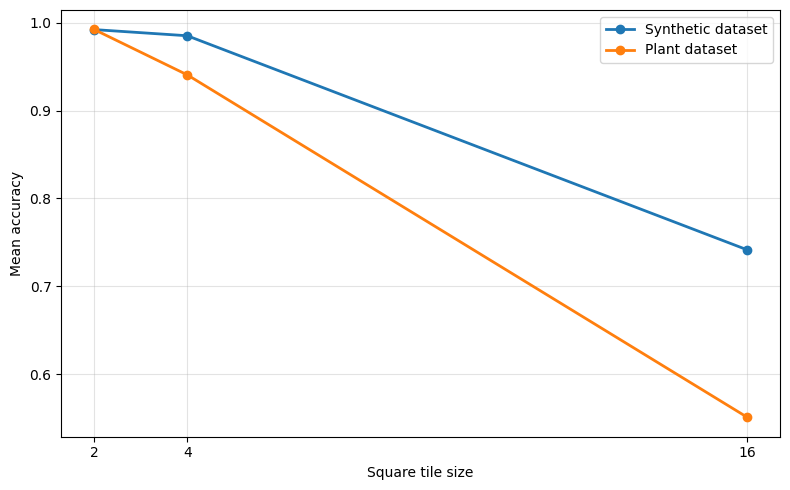

Saved: C:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\figures\tile_test_avg_classification_s.png


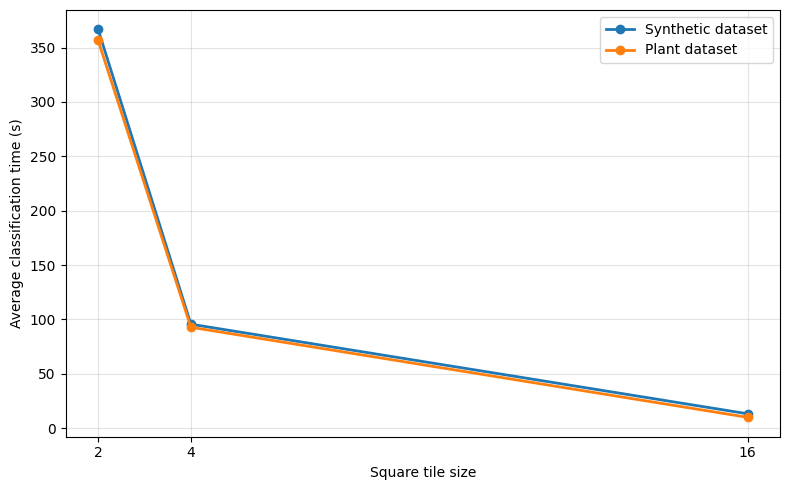

In [8]:
# Example: plot, save to disk, and display (PNG @ 300 dpi under repo `figures/`)
COLORS = ("#1f77b4", "#ff7f0e")

cwd = Path.cwd().resolve()
plot_dir = next(
    (root / "figures" for root in (cwd, cwd.parent) if (root / "circle_res.csv").is_file()),
    cwd / "figures",
)
plot_dir.mkdir(parents=True, exist_ok=True)

fig_acc, _ = plot_mean_accuracy(circle_df, plant_df, colors=COLORS, title=None)
acc_path = plot_dir / "tile_test_mean_accuracy.png"
fig_acc.savefig(acc_path, dpi=300, bbox_inches="tight")
print(f"Saved: {acc_path.resolve()}")
plt.show()

fig_time, _ = plot_avg_classification_s(circle_df, plant_df, colors=COLORS, title=None)
time_path = plot_dir / "tile_test_avg_classification_s.png"
fig_time.savefig(time_path, dpi=300, bbox_inches="tight")
print(f"Saved: {time_path.resolve()}")
plt.show()